In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from src.commons import data_loader

# 1. Optimize JupyterLab display aesthetics

In [2]:
pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(12)
pl.Config.set_float_precision(4)

polars.config.Config

# 2. Open an un-materialized high-performance file stream pointer

In [3]:
df = data_loader.read_csv("energy_storage.csv")

# 3. Data Profiling

In [4]:
# 3.1.  Energy Storage Schema
print("--- Energy Storage Schema Preview ---")
print(df.schema)

--- Energy Storage Schema Preview ---
Schema([('Storage ID', String), ('Type', String), ('Capacity KWH', Float64)])


In [5]:
# 3,2.  Energy Storage -  Data Shape & Describe Preview
print("--- Energy Storage-  Shape and Describe Preview ---")
print(df.glimpse())

--- Energy Storage-  Shape and Describe Preview ---
Rows: 20
Columns: 3
$ Storage ID   <str> 'ES-0001', 'ES-0002', 'ES-0003', 'ES-0004', 'ES-0005', 'ES-0006', 'ES-0007', 'ES-0008', 'ES-0009', 'ES-0010'
$ Type         <str> 'Lithium-Ion', 'Flow Battery', 'Pumped Hydro', 'Lithium-Ion', 'Pumped Hydro', 'Flow Battery', 'Flywheel', 'Pumped Hydro', 'Pumped Hydro', 'Lithium-Ion'
$ Capacity KWH <f64> 58825.7, 65334.8, 9360.0, 42164.9, 5119.8, 49905.1, 33656.3, 15307.9, 11236.9, 59176.8

None


# 4. Count missing values in parallel across millions of records

In [6]:
# Create a comprehensive audit summary
total_rows = df.height
null_counts = df.select(pl.all().is_null().sum())
null_pcts = df.select((pl.all().is_null().sum() / total_rows * 100).round(2))

# Reshape them vertically using unpivot
counts_vertical = null_counts.unpivot(variable_name="Column", value_name="Null Count")
pcts_vertical = null_pcts.unpivot(variable_name="Column", value_name="Null Percentage (%)")

# Join them together by the Column name
audit_df = counts_vertical.join(pcts_vertical, on="Column").sort("Null Count", descending=True)

print(audit_df)

shape: (3, 3)
┌──────────────┬────────────┬─────────────────────┐
│ Column       ┆ Null Count ┆ Null Percentage (%) │
│ ---          ┆ ---        ┆ ---                 │
│ str          ┆ u32        ┆ f64                 │
╞══════════════╪════════════╪═════════════════════╡
│ Storage ID   ┆ 0          ┆ 0.0000              │
│ Type         ┆ 0          ┆ 0.0000              │
│ Capacity KWH ┆ 0          ┆ 0.0000              │
└──────────────┴────────────┴─────────────────────┘


# 5 Plotting chart about metrics generated from the exploration.

In [7]:
# 5.1.. Calculate the metrics
total_rows = df.height

# Count actual Polars 'null' values across all columns
total_nulls = df.select(pl.all().is_null().sum()).sum_horizontal().item()


# Count empty strings ("") which often represent missing text data
string_cols = [col for col, dtype in df.schema.items() if dtype == pl.String]
if string_cols:
    total_empty_strings = df.select(pl.col(string_cols).eq("").sum()).sum_horizontal().item()
else:
    total_empty_strings = 0

In [8]:
# 5.2.. Setup data for plotting
metrics = ['Total Rows', 'Null Values', 'Missing (Empty Strings)']
counts = [total_rows, total_nulls, total_empty_strings]
colors = ['#1f77b4', '#ff7f0e', '#d62728'] # Blue, Orange, Red

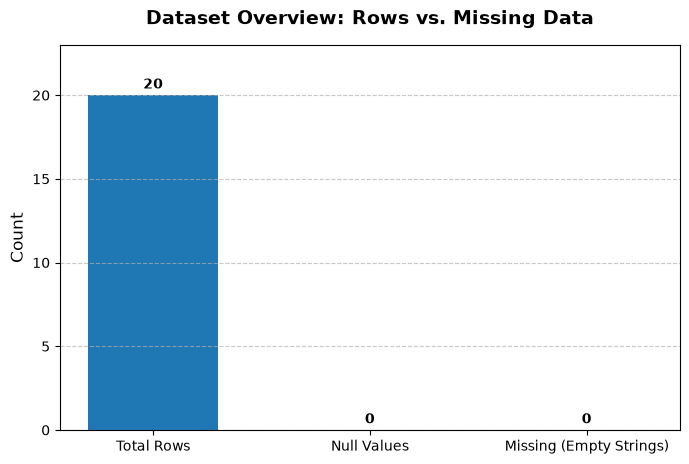

In [9]:
# 5.3. Generate the plot
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, counts, color=colors, width=0.6)

# Add exact value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (total_rows * 0.01), 
             f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Dataset Overview: Rows vs. Missing Data', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-limit to give space for labels
plt.ylim(0, max(counts) * 1.15)

plt.show()